# Restaurant Annual Turnover Prediction

This notebook builds a **regression model** to predict `Annual Turnover` for restaurants using the hackathon training and test datasets.

We will go through:
- Data loading
- Exploratory Data Analysis (EDA)
- Missing value treatment
- Feature engineering & encoding
- Model training & evaluation
- Prediction on test data
- Submission file creation


In [1]:
## Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## 1. Load the data

In [3]:
df_train = pd.read_csv('Train_dataset.csv')
df_test = pd.read_csv('Test_dataset.csv')

df_train.head()

,Registration Number,Annual Turnover,Cuisine,City,Restaurant Location,Opening Day of Restaurant,Facebook Popularity Quotient,Endorsed By,Instagram Popularity Quotient,Fire Audit,...,Overall Restaurant Rating,Live Music Rating,Comedy Gigs Rating,Value Deals Rating,Live Sports Rating,Ambience,Lively,Service,Comfortablility,Privacy
0,60001,42000000,"indian,irish",Bangalore,Near Business Hub,14-02-2009,84.3,Not Specific,95.8,1,...,10.0,4.0,NaN,NaN,NaN,8.0,8,6,6,6
1,60002,50000000,"indian,irish",Indore,Near Party Hub,29-09-2008,85.4,Tier A Celebrity,85.0,1,...,9.0,NaN,4.0,NaN,NaN,5.0,7,7,3,8
2,60003,32500000,"tibetan,italian",Chennai,Near Business Hub,30-07-2011,85.0,Tier A Celebrity,68.2,1,...,8.0,3.0,NaN,NaN,NaN,7.0,10,5,2,8
3,60004,110000000,"turkish,nigerian",Gurgaon,Near Party Hub,30-11-2008,85.6,Tier A Celebrity,83.6,0,...,9.0,6.0,NaN,NaN,NaN,7.0,7,4,3,5
4,60005,20000000,"irish,belgian",Manesar,Near Party Hub,22-02-2010,NaN,Tier A Celebrity,76.8,1,...,6.0,NaN,2.0,NaN,NaN,NaN,6,2,4,6


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3493 entries, 0 to 3492
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Registration Number            3493 non-null   int64  
 1   Annual Turnover                3493 non-null   int64  
 2   Cuisine                        3493 non-null   object 
 3   City                           3493 non-null   object 
 4   Restaurant Location            3493 non-null   object 
 5   Opening Day of Restaurant      3493 non-null   object 
 6   Facebook Popularity Quotient   3394 non-null   float64
 7   Endorsed By                    3493 non-null   object 
 8   Instagram Popularity Quotient  3437 non-null   float64
 9   Fire Audit                     3493 non-null   int64  
 10  Liquor License Obtained        3493 non-null   int64  
 11  Situated in a Multi Complex    3493 non-null   int64  
 12  Dedicated Parking              3493 non-null   i

In [5]:
df_train.isnull().sum()

,0
Registration Number,0
Annual Turnover,0
Cuisine,0
City,0
Restaurant Location,0
Opening Day of Restaurant,0
Facebook Popularity Quotient,99
Endorsed By,0
Instagram Popularity Quotient,56
Fire Audit,0


From the original sample code, we know there are missing values in columns like:
- `Facebook Popularity Quotient`
- `Instagram Popularity Quotient`
- Several rating columns (e.g., `Live Music Rating`, `Comedy Gigs Rating`, `Value Deals Rating`, `Live Sports Rating`, etc.)

We will handle missing values separately for numeric and categorical features.

## 2. Basic EDA

In [6]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_cols, categorical_cols

(['Registration Number',
  'Annual Turnover',
  'Facebook Popularity Quotient',
  'Instagram Popularity Quotient',
  'Fire Audit',
  'Liquor License Obtained',
  'Situated in a Multi Complex',
  'Dedicated Parking',
  'Open Sitting Available',
  'Resturant Tier',
  'Restaurant Zomato Rating',
  'Restaurant City Tier',
  'Order Wait Time',
  'Staff Responsivness',
  'Value for Money',
  'Hygiene Rating',
  'Food Rating',
  'Overall Restaurant Rating',
  'Live Music Rating',
  'Comedy Gigs Rating',
  'Value Deals Rating',
  'Live Sports Rating',
  'Ambience',
  'Lively',
  'Service',
  'Comfortablility',
  'Privacy'],
 ['Cuisine',
  'City',
  'Restaurant Location',
  'Opening Day of Restaurant',
  'Endorsed By',
  'Restaurant Type',
  'Restaurant Theme'])

In [7]:
df_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Registration Number,3493.0,6.174700e+04,1.008487e+03,60001.0,60874.0,61747.00,6.262000e+04,6.349300e+04
Annual Turnover,3493.0,3.072571e+07,2.165125e+07,3500000.0,18000000.0,30000000.00,3.700000e+07,4.000000e+08
Facebook Popularity Quotient,3394.0,7.793872e+01,9.829169e+00,43.0,72.0,79.00,8.574500e+01,9.776000e+01
Instagram Popularity Quotient,3437.0,7.440468e+01,1.094033e+01,40.0,66.0,74.05,8.240000e+01,9.870000e+01
Fire Audit,3493.0,7.887203e-01,4.082748e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Liquor License Obtained,3493.0,9.882622e-01,1.077187e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Situated in a Multi Complex,3493.0,8.081878e-01,3.937825e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Dedicated Parking,3493.0,8.018895e-01,3.986329e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Open Sitting Available,3493.0,8.001718e-01,3.999284e-01,0.0,1.0,1.00,1.000000e+00,1.000000e+00
Resturant Tier,3444.0,1.926539e+00,2.609297e-01,1.0,2.0,2.00,2.000000e+00,2.000000e+00


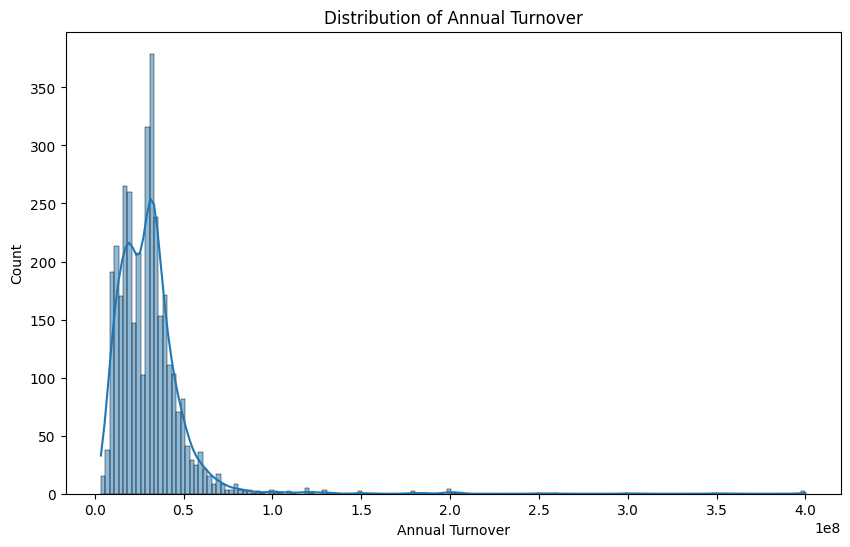

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df_train['Annual Turnover'], kde=True)
plt.title('Distribution of Annual Turnover')
plt.show()

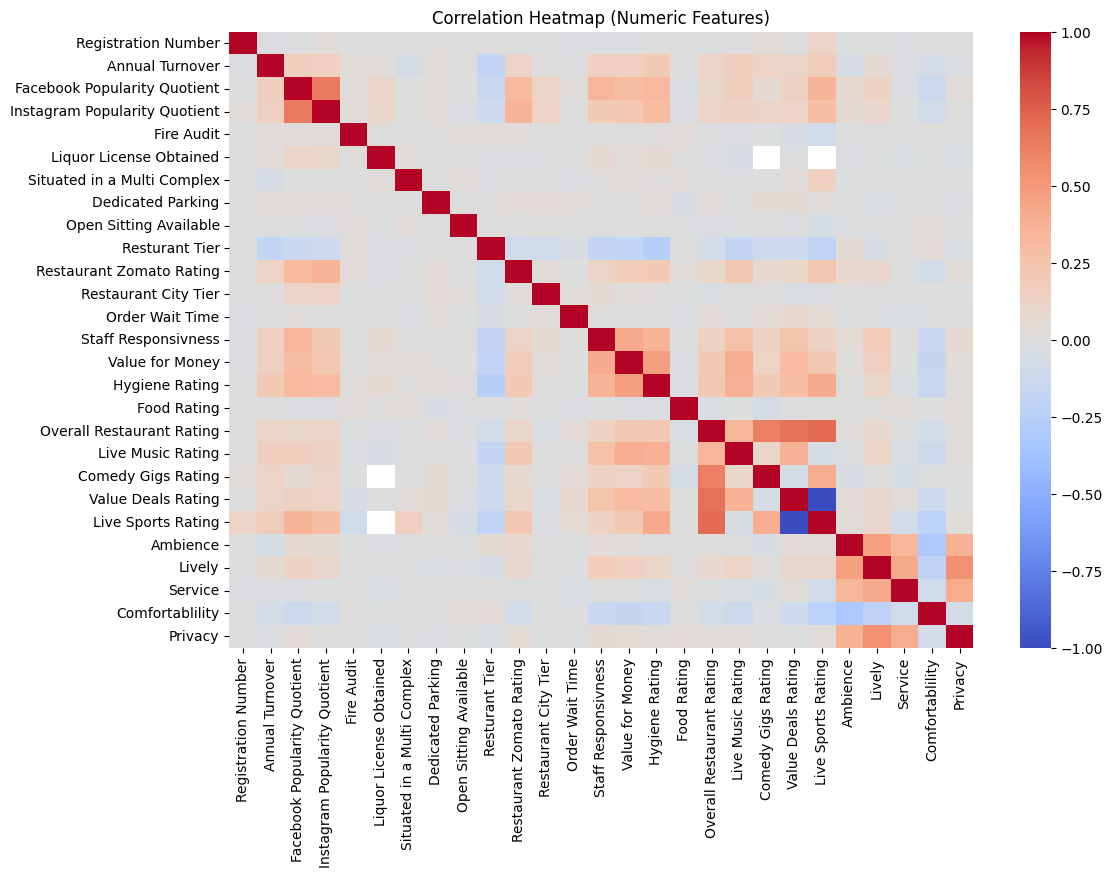

In [10]:
corr = df_train[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

## 3. Feature selection & preprocessing

From the original hackathon sample code, we know they used:
- `Instagram Popularity Quotient` as a key predictor
- `Annual Turnover` as the target

We will build a richer model using multiple features, but still include `Instagram Popularity Quotient` explicitly.

We will:
- Treat **numeric features** with mean imputation
- Treat **categorical features** with most-frequent imputation + one-hot encoding


In [13]:
target_col = 'Annual Turnover'
id_cols = ['Registration Number']

# 1. Get features from train excluding target and ID columns
train_features = [c for c in df_train.columns if c not in [target_col] + id_cols]

# 2. Keep ONLY features that also exist in the test dataset to prevent KeyErrors
feature_cols = [c for c in train_features if c in df_test.columns]

# 3. Define your matrices safely
X = df_train[feature_cols]
y = df_train[target_col]
X_test_full = df_test[feature_cols]

# 4. Separate numeric and categorical features based on the final feature list
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Features used for training: {len(feature_cols)}")
if 'Endorsed By' not in df_test.columns:
    print("Note: 'Endorsed By' was safely dropped because it doesn't exist in the test set.")

Features used for training: 31
Note: 'Endorsed By' was safely dropped because it doesn't exist in the test set.


In [14]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## 4. Train–test split and model training

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_valid)

# FIXED: Use np.sqrt() to calculate RMSE instead of squared=False
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
r2 = r2_score(y_valid, y_pred)

rmse, r2

(np.float64(24041390.62895496), -0.2712282615397239)

## 5. Error analysis

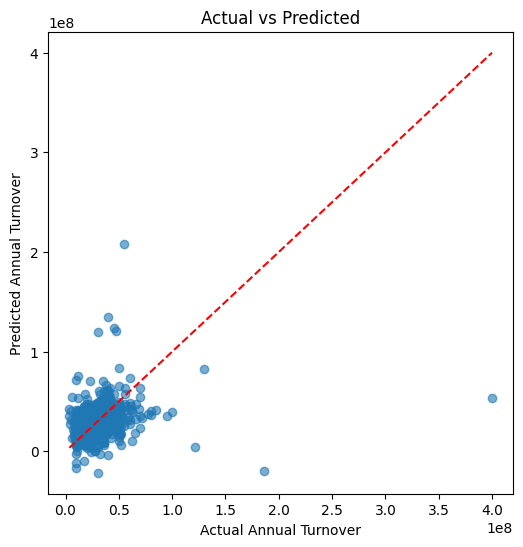

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_valid, y_pred, alpha=0.6)
plt.xlabel('Actual Annual Turnover')
plt.ylabel('Predicted Annual Turnover')
plt.title('Actual vs Predicted')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--')
plt.show()

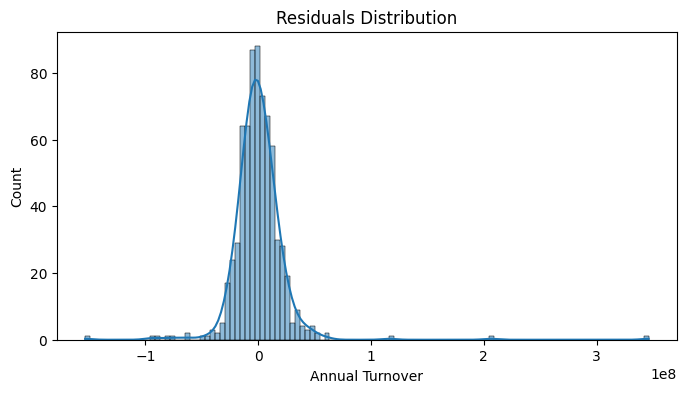

In [17]:
residuals = y_valid - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution')
plt.show()

## 6. Simple model using only Instagram Popularity Quotient (to mirror sample code)

The original hackathon sample code specifically showed:

```python
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

SI = SimpleImputer(strategy='mean')
SI.fit(df_train[[' Instagram Popularity Quotient']])
IPQ = SI.transform(df_train[[' Instagram Popularity Quotient']])

LR = LinearRegression()
model_simple = LR.fit(IPQ, df_train[' Annual Turnover'])
model_simple.score(IPQ, df_train[' Annual Turnover'])
```

We reproduce that here as a baseline.

In [21]:
SI = SimpleImputer(strategy='mean')
IPQ_train = SI.fit_transform(df_train[['Instagram Popularity Quotient']])

LR_simple = LinearRegression()
model_simple = LR_simple.fit(IPQ_train, df_train['Annual Turnover'])

simple_score = model_simple.score(IPQ_train, df_train['Annual Turnover'])
simple_score

0.026482712263984687

## 7. Train final model on full training data

We now retrain the **full feature model** on all available training data and then predict on the test set.

In [20]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

final_model.fit(X, y)

test_predictions = final_model.predict(X_test_full)
test_predictions[:5]

array([27885322.45032395, 39273898.58634785, 35295118.96135769,
       43424082.90542792, 30729786.13366887])

## 8. Create submission file

The original sample code shows building a solution dataframe using `Registration Number` and predicted `Annual Turnover` and then saving it as `Submission.csv`.

In [22]:
solution_df = pd.DataFrame()
solution_df['Registration Number'] = df_test['Registration Number']
solution_df[' Annual Turnover'] = test_predictions

solution_df.head()

,Registration Number,Annual Turnover
0,20001,2.788532e+07
1,20002,3.927390e+07
2,20003,3.529512e+07
3,20004,4.342408e+07
4,20005,3.072979e+07


In [24]:
from google.colab import files

# Save the dataframe to a CSV in the Colab environment
solution_df.to_csv('Submission.csv', index=False)
print('Submission.csv has been created.')

# Trigger the browser to download the file
files.download('Submission.csv')

Submission.csv has been created.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# End of Notebook

You can now submit `Submission.csv` to the hackathon platform or use it for further analysis.